# 0. Before we start

To be 100% honest, It has been a long time I did this analysis on my own. (without LLMs' help) quite long time ago, so it is fair to say that I am fairly rusty on this.
But I'll pull through and try my best to only refer to official documentations and simple websearch as much as I can.


# 1. Experimental setup

We have pytorch, numpy and matplotlib. I am not sure if we can even use pandas on this. I mean afaik, we can 'convert' the dataset samples into pandas DF. But MNIST hand \

drawn digits are not that deep when we really think about it. At least compared to the famous Californa Housing Prediction. MNIST does not have a human-interpretable 

'features' that we can extract. That's exactly why we construct such Multi-Layered , Fully connected 'Black-Box' of a neural network.

One of the easiest and simplest analysis that I can think of right away is that we can analyze the 'distribution' of digits. 

So for example , how much digit 0s we have out of the whole dataset. 

We could then count it on the whole dataset and then only on the train/test/valid subsets for all digits. Thus using matplotlib we can create a figure to visualize it.

Then we could also do a simple numerical analysis like is the black and white picture's pixel values are from 0 to 255 or normalized to 0 to 1 etc...

## Distributions of Digits

let's try to count first

In [ ]:
# So like, let's create a variable to hold the counted digits

#digit_count = 0

# we have data/train/idx/ data/train/images/ data/train/labels
# and most of it is .npy files, so first we should def import numpy library
# /idx is ignored, 
# /images folder has the 28x28 'pixel' images
# /labels should be the folder that we should pay attention for counting
# ofc, we also need path library since we are messing with OS files
from pathlib import Path
import os #probably not needed.
import numpy as np

# instead of a single variable digit_count, I think it should be list (array) 
# that should hold from index 0 : digit 0 to index 9 : digit 9 , and their respective counts. 
# on second tought we could also use dictionary
# or even a numpy array

digits_count = [0,0,0,0,0,0,0,0,0,0]

# anyways now the hard part:

# so the main idea is to loop over the {test,train,valid}/labels/*.npy files
# extract the labels and if it's digit i increment the digits_count's corresponding index value
# let's start simple with single file .npy laoding

npy_label = np.load('/home/turu/Documents/FUTURE/Hand-Drawn-Doodle-Classsifier/data/test/labels/test_000000.npy')

print(npy_label)



FileNotFoundError: [Errno 2] No such file or directory: '/home/turu/Documents/FUTURE/Hand-Drawn-Doodle-Classsifier/data/test/labels/*.npy'

In [ ]:
# p = Path('../../data') ## this is gonna bite me later down the road...
# I should figure out to put the current project root directory
# 
proj_root = Path.cwd().parent.parent
print(proj_root)

label_path = proj_root / 'data'

list(label_path.glob('**/labels/*.npy')) # I really hope that this only lists all the .npy labels across the 3 directories
# print(lists)
# next thing I should do is 'iterate/loop' over the files and 'print' their label numbers
# To loop, I need to first know how many labels .npy files I have


/home/turu/Documents/FUTURE/Hand-Drawn-Doodle-Classsifier


[PosixPath('/home/turu/Documents/FUTURE/Hand-Drawn-Doodle-Classsifier/data/valid/labels/valid_001271.npy'),
 PosixPath('/home/turu/Documents/FUTURE/Hand-Drawn-Doodle-Classsifier/data/valid/labels/valid_001259.npy'),
 PosixPath('/home/turu/Documents/FUTURE/Hand-Drawn-Doodle-Classsifier/data/valid/labels/valid_002893.npy'),
 PosixPath('/home/turu/Documents/FUTURE/Hand-Drawn-Doodle-Classsifier/data/valid/labels/valid_002888.npy'),
 PosixPath('/home/turu/Documents/FUTURE/Hand-Drawn-Doodle-Classsifier/data/valid/labels/valid_006747.npy'),
 PosixPath('/home/turu/Documents/FUTURE/Hand-Drawn-Doodle-Classsifier/data/valid/labels/valid_006666.npy'),
 PosixPath('/home/turu/Documents/FUTURE/Hand-Drawn-Doodle-Classsifier/data/valid/labels/valid_004981.npy'),
 PosixPath('/home/turu/Documents/FUTURE/Hand-Drawn-Doodle-Classsifier/data/valid/labels/valid_002083.npy'),
 PosixPath('/home/turu/Documents/FUTURE/Hand-Drawn-Doodle-Classsifier/data/valid/labels/valid_008782.npy'),
 PosixPath('/home/turu/Docum

In [ ]:
# Next challenge is to know how many labels are we going to loop
# big clue is that we can use this : list(label_path.glob('**/labels/*.npy')) 
label_list = list(label_path.glob('**/labels/*.npy'))
# label_list
# len() was the answer to this...
len(label_list)
# print(label_list.size)


70000

In [ ]:
# L = len(label_list)
# for f in L:
  # pass -> soyboy, beta way

TypeError: 'int' object is not iterable

In [ ]:
# chad , man way:
for file in label_path.glob('**/labels/*.npy'):
  # print(file)
  npy_label = np.load(file)
  # print(npy_label)
  # print(type(npy_label))
  digits_count[npy_label] += 1 # this is so elegant solution OMG
  # print(npy_label.shape) 


In [84]:
print(digits_count)
print(len(digits_count))

[6903, 7877, 6990, 7141, 6824, 6313, 6876, 7293, 6825, 6958]
10


In [90]:
dgt_cnt_p = [0.0] * 10
# for i in digits_count:
  # print(i)
  # print((i/70000) * 100)
  # dgt_cnt_p[i] = (i/70000) * 100 # This is wrong because i is not 0 ,1 , 2 (idx) its instead the 6903, 7877 ...

for idx in range(len(digits_count)):
  # print(digits_count[idx])
  dgt_cnt_p[idx] = digits_count[idx] / 70000 * 100


In [91]:
print(dgt_cnt_p)

[9.86142857142857, 11.252857142857142, 9.985714285714286, 10.20142857142857, 9.748571428571429, 9.018571428571429, 9.822857142857142, 10.418571428571429, 9.75, 9.94]


([<matplotlib.patches.Wedge at 0x73f9d702c860>,
 [Text(1.0476320302628206, 0.3353611921009952, '0'),
  Text(0.6189856137812257, 0.9093166719751044, '1'),
  Text(-0.07645846905235487, 1.0973395566141642, '2'),
  Text(-0.7117992862718054, 0.8386547418711402, '3'),
  Text(-1.0683966913519933, 0.261779506279834, '4'),
  Text(-1.0335738538593824, -0.37646392737985396, '5'),
  Text(-0.6476816362858561, -0.8891054481995239, '6'),
  Text(0.006960358667761762, -1.0999779786010337, '7'),
  Text(0.6568639704894081, -0.8823433142903562, '8'),
  Text(1.0468010503126361, -0.33794609195012426, '9')])

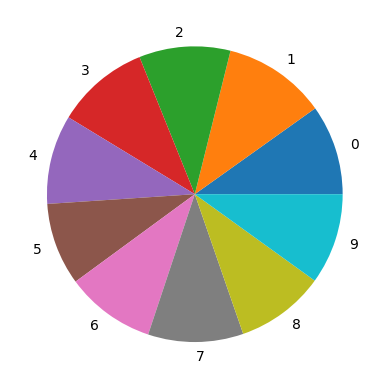

In [93]:
# now I want to use piechart to visualize the percentages of each digits :
import matplotlib.pyplot as plt


labels = '0' , '1' , '2' , '3', '4' , '5' , '6' , '7' , '8' , '9'
fig, ax = plt.subplots()
ax.pie(dgt_cnt_p, labels=labels)

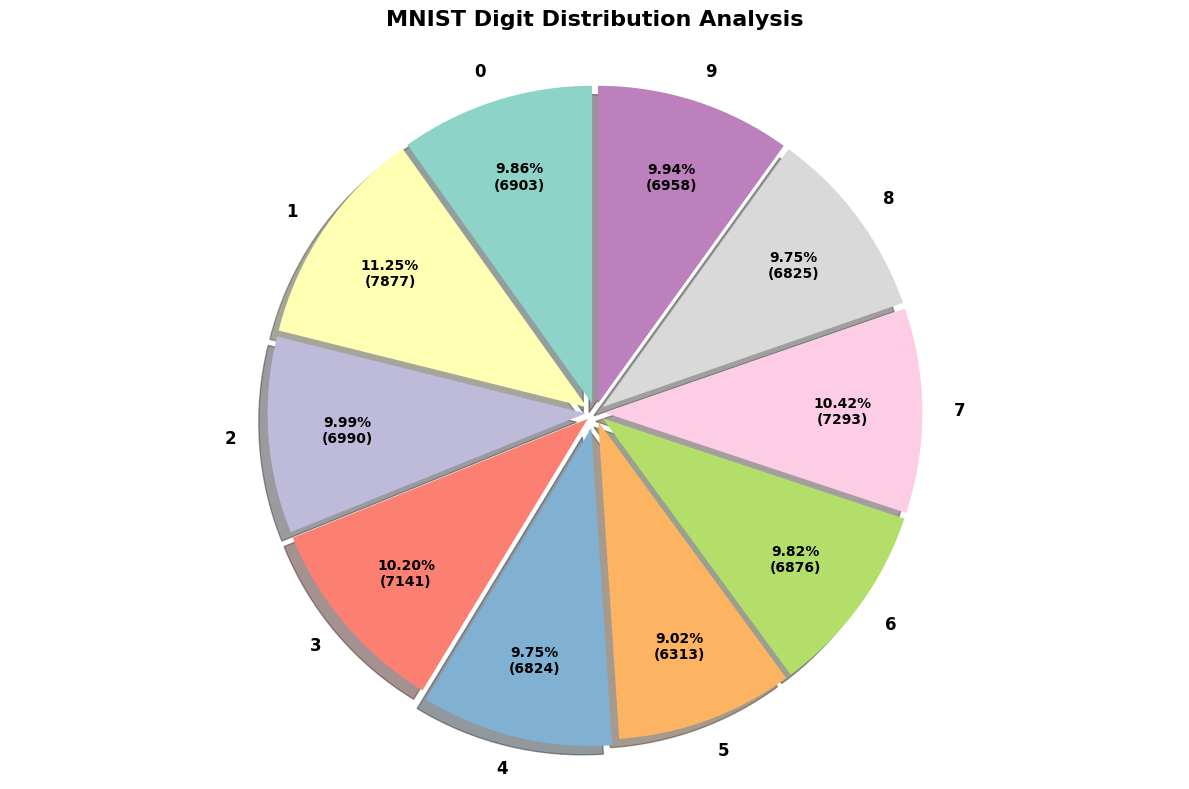

In [95]:
## DeepSeek implemented for visual 'improvement'
import matplotlib.pyplot as plt

labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

fig, ax = plt.subplots(figsize=(12, 8))

# Custom autopct function to show both percentage and count
def make_autopct(counts):
    def autopct(pct):
        total = sum(counts)
        val = int(round(pct * total / 100.0))
        return f'{pct:.2f}%\n({val})'
    return autopct

wedges, texts, autotexts = ax.pie(
    dgt_cnt_p,
    labels=labels,
    autopct=make_autopct(digits_count),
    startangle=90,
    explode=[0.03 if i != 4 else 0.05 for i in range(10)],  # Slightly more explode for a specific digit if desired
    shadow=True,
    colors=plt.cm.Set3(range(10)),  # Colorful colormap
    textprops={'fontsize': 11},
    pctdistance=0.75
)

# Enhance text styling
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

ax.set_title('MNIST Digit Distribution Analysis', fontsize=16, fontweight='bold', pad=20)
ax.axis('equal')

plt.tight_layout()
plt.show()